Dataset:
    age  experience  performance_score  projects  overtime_hours education  \
0    24           1                 62         2               5  Bachelor   
1    28           3                 78         4              10    Master   
2    35           8                 85         6              12    Master   
3    42          15                 72         5               8  Bachelor   
4    25           2                 55         1               2  Bachelor   
5    31           6                 91         7              15    Master   
6    39          12                 88         8              20       PhD   
7    45          18                 65         4               5  Bachelor   
8    27           4                 69         3               6  Bachelor   
9    33           7                 82         5              11    Master   
10   29           5                 74         4               9  Bachelor   
11   41          14                 93         9       

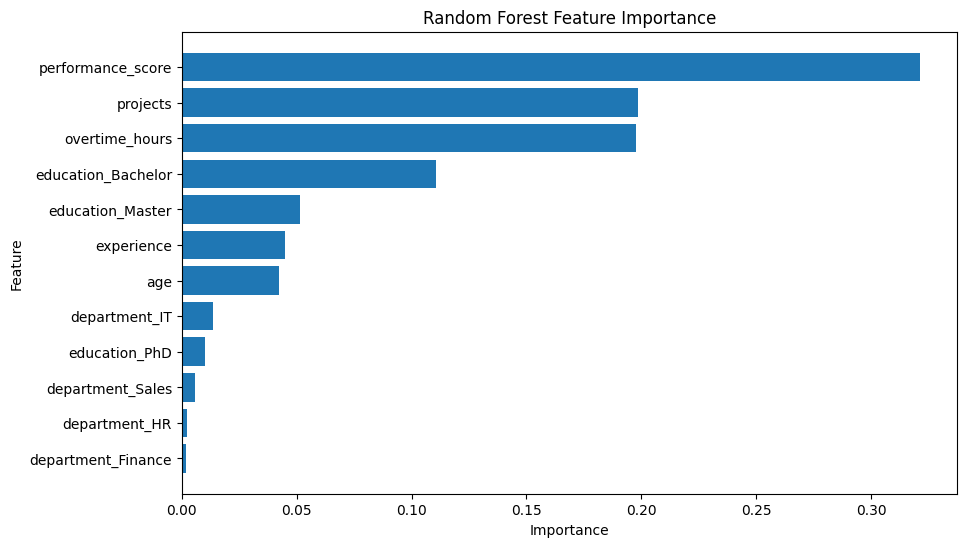

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# 1. CREATE DATASET
# ============================================================

age = [
    24,28,35,42,25,31,39,45,27,33,
    29,41,23,36,48,30,26,38,44,32,
    37,29,34,40,27,43,25,35,31,46,
    28,39,33,42,24,36,30,45,26,34,
    41,29,38,47,32,27,40,35,43,31
]

experience = [
    1,3,8,15,2,6,12,18,4,7,
    5,14,1,10,22,5,2,11,17,6,
    9,4,8,13,3,16,1,9,5,20,
    4,12,7,15,1,10,5,19,2,8,
    14,5,11,21,6,3,13,9,17,7
]

performance_score = [
    62,78,85,72,55,91,88,65,69,82,
    74,93,48,79,71,87,66,84,76,59,
    90,61,77,68,83,89,57,73,81,63,
    70,86,64,80,52,92,67,83,73,89,
    62,85,75,58,88,60,91,69,82,78
]

projects = [
    2,4,6,5,1,7,8,4,3,5,
    4,9,1,6,3,6,2,7,5,2,
    8,3,5,4,5,7,2,4,6,3,
    3,7,3,6,1,8,3,6,3,7,
    4,6,5,2,7,2,8,4,6,5
]

overtime_hours = [
    5,10,12,8,2,15,20,5,6,11,
    9,18,3,7,4,14,4,13,6,3,
    17,5,10,4,12,16,2,8,13,5,
    7,15,4,9,1,19,6,11,8,16,
    3,14,9,2,15,4,18,5,12,10
]

education = [
    "Bachelor","Master","Master","Bachelor","Bachelor",
    "Master","PhD","Bachelor","Bachelor","Master",
    "Bachelor","PhD","Bachelor","Master","Bachelor",
    "Master","Bachelor","Master","Bachelor","Bachelor",
    "PhD","Bachelor","Master","Bachelor","Master",
    "PhD","Bachelor","Bachelor","Master","Bachelor",
    "Bachelor","Master","Bachelor","Master","Bachelor",
    "PhD","Bachelor","Master","Bachelor","Master",
    "Bachelor","Master","Bachelor","Bachelor","Master",
    "Bachelor","PhD","Bachelor","Master","Bachelor"
]

department = [
    "IT","IT","Finance","HR","Sales",
    "IT","IT","Finance","HR","Sales",
    "IT","Finance","Sales","HR","HR",
    "IT","Finance","Sales","Finance","HR",
    "IT","Sales","Finance","HR","IT",
    "Finance","HR","Sales","IT","Finance",
    "HR","IT","Sales","Finance","HR",
    "IT","Finance","Sales","IT","HR",
    "Sales","Finance","HR","IT","Sales",
    "Finance","HR","Finance","HR","IT"
]

promoted = [
    0,1,1,1,0,1,1,0,0,1,
    1,1,0,1,0,1,0,1,1,0,
    1,0,1,0,1,1,0,1,1,0,
    0,1,0,1,0,1,0,1,0,1,
    0,1,1,0,1,0,1,0,1,1
]


df = pd.DataFrame({
    "age": age,
    "experience": experience,
    "performance_score": performance_score,
    "projects": projects,
    "overtime_hours": overtime_hours,
    "education": education,
    "department": department,
    "promoted": promoted
})


print("Dataset:")
print(df)


# ============================================================
# 1. X AND y
# ============================================================

X = df.drop("promoted", axis=1)
y = df["promoted"]


# ============================================================
# 2. ONE-HOT ENCODING
# ============================================================

categorical_columns = ["education", "department"]

encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

encoded_data = encoder.fit_transform(
    X[categorical_columns]
)

encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(categorical_columns),
    index=X.index
)

# Remove original categorical columns
X = X.drop(categorical_columns, axis=1)

# Add encoded columns
X = pd.concat([X, encoded_df], axis=1)


# ============================================================
# 3. TRAIN TEST SPLIT
# ============================================================

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ============================================================
# 4. CREATE RANDOM FOREST
# ============================================================

model = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=5,
    random_state=42
)


# ============================================================
# 5. TRAIN
# ============================================================

model.fit(x_train, y_train)


# ============================================================
# 6. PREDICTION
# ============================================================

y_pred = model.predict(x_test)

print("Predictions:")
print(y_pred)

print("\nActual:")
print(y_test.values)


# ============================================================
# 7. ACCURACY
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)


# ============================================================
# 8. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# ============================================================
# 9. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)


# ============================================================
# 10. FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(feature_importance)


# ============================================================
# 11. PLOT FEATURE IMPORTANCE
# ============================================================

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()